In [4]:
# 必要なライブラリをインポート
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib # モデルの保存に使用
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import os

# --- 1. データの読み込み ---
features_data_path = '../data/processed/features.parquet'
df = pd.read_parquet(features_data_path)

In [5]:
df.head()

,市区町村コード,都道府県名,市区町村名,地区名,最寄駅：名称,最寄駅：距離（分）,間取り,面積（㎡）,建築年,建物の構造,...,築年数×面積×駅距離,面積×建ぺい率×容積率,建ぺい率_頻度,容積率_頻度,市区町村_頻度,市区町村_頻度_log,駅名_頻度,駅名_頻度_log,地区名_頻度,地区名_頻度_log
0,1108,北海道,札幌市厚別区,大谷地東,大谷地,8.0,３ＬＤＫ,80,1995.0,ＳＲＣ,...,8960.0,960000.0,305296,253940,1128,7.029088,417,6.035481,318.0,5.765191
1,1101,北海道,札幌市中央区,南９条西,中島公園,5.0,１ＤＫ,30,1982.0,ＳＲＣ,...,5400.0,720000.0,229569,79069,5012,8.519790,425,6.054439,224.0,5.416100
2,1101,北海道,札幌市中央区,北３条西,西１１丁目,11.0,３ＬＤＫ,65,1991.0,ＳＲＣ,...,13585.0,1560000.0,229569,79069,5012,8.519790,537,6.287859,179.0,5.192957
3,1108,北海道,札幌市厚別区,厚別中央２条,ひばりが丘(北海道),5.0,４ＬＤＫ,90,2015.0,ＲＣ,...,0.0,2880000.0,229569,97066,1128,7.029088,173,5.159055,78.0,4.369448
4,1108,北海道,札幌市厚別区,厚別東４条,新さっぽろ,12.0,４ＬＤＫ,80,1982.0,ＲＣ,...,28800.0,960000.0,305296,253940,1128,7.029088,277,5.627621,44.0,3.806662


In [30]:
df.columns

Index(['ID', '種類', '市区町村コード', '都道府県名', '市区町村名', '地区名', '最寄駅：名称', '最寄駅：距離（分）',
       '間取り', '面積（㎡）', '建築年', '建物の構造', '用途', '今後の利用目的', '都市計画', '建ぺい率（％）',
       '容積率（％）', '取引時点', '取引価格（総額）_log', '取引時点での築年数', '人口密度', '市区町村人口密度',
       '取引の事情等_その他事情有り', '取引の事情等_他の権利・負担付き', '取引の事情等_他の権利・負担付き、調停・競売等',
       '取引の事情等_瑕疵有りの可能性', '取引の事情等_調停・競売等', '取引の事情等_調停・競売等、瑕疵有りの可能性',
       '取引の事情等_関係者間取引', '取引の事情等_関係者間取引、瑕疵有りの可能性', '取引の事情等_関係者間取引、調停・競売等',
       '取引の事情等_その他', '改装_改装済', '改装_未改装', '間取り_grouped_その他',
       '間取り_grouped_オープンフロア', '間取り_grouped_欠損値', '間取り_grouped_１ＤＫ',
       '間取り_grouped_１Ｋ', '間取り_grouped_１ＬＤＫ', '間取り_grouped_１Ｒ',
       '間取り_grouped_２ＤＫ', '間取り_grouped_２Ｋ', '間取り_grouped_２ＬＤＫ',
       '間取り_grouped_２ＬＤＫ＋Ｓ', '間取り_grouped_３ＤＫ', '間取り_grouped_３ＬＤＫ',
       '間取り_grouped_４ＤＫ', '間取り_grouped_４ＬＤＫ', '築年数_2乗', '築年数_3乗', '築年数_log',
       '面積_log', '面積_平方根', '築年数×面積', '築年数×駅距離', '築年数×建ぺい率', '築年数×容積率',
       '築年数×人口密度', '面積×駅距離', '面積×建ぺい率', '面積×容積率', '面積×人口密度', '建築可能性',
       '容積率_建ぺい率比

# LightGBM

In [6]:
!pip install lightgbm

In [7]:

import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## モデル構築

In [8]:
df.columns

Index(['市区町村コード', '都道府県名', '市区町村名', '地区名', '最寄駅：名称', '最寄駅：距離（分）', '間取り',
       '面積（㎡）', '建築年', '建物の構造', '用途', '今後の利用目的', '都市計画', '建ぺい率（％）', '容積率（％）',
       '取引時点', '取引価格（総額）_log', '取引時点での築年数', '取引の事情等_その他事情有り',
       '取引の事情等_他の権利・負担付き', '取引の事情等_他の権利・負担付き、調停・競売等', '取引の事情等_瑕疵有りの可能性',
       '取引の事情等_調停・競売等', '取引の事情等_調停・競売等、瑕疵有りの可能性', '取引の事情等_関係者間取引',
       '取引の事情等_関係者間取引、瑕疵有りの可能性', '取引の事情等_関係者間取引、調停・競売等', '取引の事情等_その他',
       '改装_改装済', '改装_未改装', '間取り_grouped_その他', '間取り_grouped_オープンフロア',
       '間取り_grouped_欠損値', '間取り_grouped_１ＤＫ', '間取り_grouped_１Ｋ',
       '間取り_grouped_１ＬＤＫ', '間取り_grouped_１Ｒ', '間取り_grouped_２ＤＫ',
       '間取り_grouped_２Ｋ', '間取り_grouped_２ＬＤＫ', '間取り_grouped_２ＬＤＫ＋Ｓ',
       '間取り_grouped_３ＤＫ', '間取り_grouped_３ＬＤＫ', '間取り_grouped_４ＤＫ',
       '間取り_grouped_４ＬＤＫ', '築年数_2乗', '築年数_3乗', '築年数_log', '面積_log', '面積_平方根',
       '築年数×面積', '築年数×駅距離', '築年数×建ぺい率', '築年数×容積率', '人口密度', '市区町村人口密度',
       '築年数×人口密度', '面積×駅距離', '面積×建ぺい率', '面積×容積率', '面積×人口密度', '建築可能性',
       '容積率_建ぺい率比', '建ぺい率_2乗'

In [9]:

# --- 説明変数・目的変数のセット ---
X = df[['市区町村コード', '都道府県名', '市区町村名', '地区名', '最寄駅：名称','最寄駅：距離（分）',
        '取引時点での築年数', '取引の事情等_その他事情有り', '取引の事情等_他の権利・負担付き',
        '取引の事情等_他の権利・負担付き、調停・競売等', '取引の事情等_瑕疵有りの可能性',
        '取引の事情等_調停・競売等', '取引の事情等_調停・競売等、瑕疵有りの可能性',
        '取引の事情等_関係者間取引', '取引の事情等_関係者間取引、瑕疵有りの可能性',
        '取引の事情等_関係者間取引、調停・競売等', '改装_改装済', '間取り_grouped_オープンフロア',
        '間取り_grouped_欠損値', '間取り_grouped_１ＤＫ', '間取り_grouped_１Ｋ',
        '間取り_grouped_１ＬＤＫ', '間取り_grouped_１Ｒ', '間取り_grouped_２ＤＫ',
        '間取り_grouped_２Ｋ', '間取り_grouped_２ＬＤＫ', '間取り_grouped_２ＬＤＫ＋Ｓ',
        '間取り_grouped_３ＤＫ', '間取り_grouped_３ＬＤＫ', '間取り_grouped_４ＤＫ',
        '間取り_grouped_４ＬＤＫ','人口密度','築年数_2乗',
       '面積_log', '面積_平方根',  '築年数×駅距離', '築年数×建ぺい率', 
       '面積×建ぺい率', '面積×人口密度', '築年数×面積×駅距離', '面積×建ぺい率×容積率', '取引月', '取引四半期', '取引年', '取引曜日', '建ぺい率_頻度',
       '容積率_頻度', '市区町村_頻度', '市区町村_頻度_log', '駅名_頻度', '駅名_頻度_log', '地区名_頻度',
       '地区名_頻度_log' ]]

Y = df['取引価格（総額）_log']


KeyError: "['取引月', '取引四半期', '取引年', '取引曜日'] not in index"

## 実行・結果

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import numpy as np

# --- カテゴリ変数の数値化 ---
categorical_features = ['都道府県名', '市区町村名', '地区名', '最寄駅：名称']

# Xをコピー（元データを変更しないため）
X_encoded = X.copy()

# Label Encoding
label_encoders = {}
for col in categorical_features:
    if col in X_encoded.columns:
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
        label_encoders[col] = le

print(f"✓ カテゴリ変数を数値化しました")
print(f"特徴量数: {X_encoded.shape[1]}")

# --- データ分割 ---
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, Y, test_size=0.2, random_state=42
)

# --- LightGBM モデル構築 ---
model_lgb = lgb.LGBMRegressor(
    objective='regression_l1',  # MAEを最適化
    metric='mae',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1  # 学習ログを抑制（必要なら削除）
)

# --- 学習 ---
print("\n学習開始...")
model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_names=['train', 'valid'],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

print(f"\n✓ 学習完了 (best iteration: {model_lgb.best_iteration_})")

# --- 予測と評価 ---
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_train = model_lgb.predict(X_train)
y_pred_test = model_lgb.predict(X_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"\n=== LightGBM 評価結果 ===")
print(f"【Train】")
print(f"  MAE:  {mae_train:.4f}")
print(f"  RMSE: {rmse_train:.4f}")
print(f"  R²:   {r2_train:.4f}")
print(f"\n【Test】")
print(f"  MAE:  {mae_test:.4f}")
print(f"  RMSE: {rmse_test:.4f}")
print(f"  R²:   {r2_test:.4f}")


✓ カテゴリ変数を数値化しました
特徴量数: 53

学習開始...
Training until validation scores don't improve for 50 rounds
[100]	train's l1: 0.112015	valid's l1: 0.11229
[200]	train's l1: 0.104155	valid's l1: 0.104634
[300]	train's l1: 0.101076	valid's l1: 0.10175
[400]	train's l1: 0.0991524	valid's l1: 0.100058
[500]	train's l1: 0.0976252	valid's l1: 0.0987434
[600]	train's l1: 0.0964155	valid's l1: 0.0977504
[700]	train's l1: 0.0952641	valid's l1: 0.0968104
[800]	train's l1: 0.0943694	valid's l1: 0.0961442
[900]	train's l1: 0.0935935	valid's l1: 0.0955774
[1000]	train's l1: 0.092895	valid's l1: 0.0950792
Did not meet early stopping. Best iteration is:
[1000]	train's l1: 0.092895	valid's l1: 0.0950792

✓ 学習完了 (best iteration: 1000)

=== LightGBM 評価結果 ===
【Train】
  MAE:  0.0929
  RMSE: 0.1431
  R²:   0.8318

【Test】
  MAE:  0.0951
  RMSE: 0.1463
  R²:   0.8253


In [42]:
# MAE計算

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 予測
y_pred = model_lgb.predict(X_test)

# 評価指標
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 0.0951
RMSE: 0.1463


In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# --- VIF計算用のデータ準備 ---
# カテゴリ変数を除外するか、数値化する

# 方法1: カテゴリ変数を除外して計算
categorical_cols = ['都道府県名', '市区町村名', '地区名', '最寄駅：名称']
X_numeric = X.drop(columns=categorical_cols, errors='ignore')

# 欠損値を除去
X_numeric = X_numeric.dropna()

# VIF計算
vif = pd.DataFrame()
vif["変数名"] = X_numeric.columns
vif["VIF"] = [variance_inflation_factor(X_numeric.values, i) for i in range(X_numeric.shape[1])]

# VIFでソート
vif = vif.sort_values('VIF', ascending=False)

print("=== VIF（多重共線性チェック）===")
print("※ VIF > 10 は多重共線性の可能性が高い")
print("\n")
display(vif)

# VIF > 10 の変数を表示
high_vif = vif[vif['VIF'] > 10]
if len(high_vif) > 0:
    print(f"\n⚠️ VIF > 10 の変数（{len(high_vif)}個）:")
    display(high_vif)
else:
    print("\n✓ VIF > 10 の変数はありません")

\\?\C:\Users\sabri\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


=== VIF（多重共線性チェック）===
※ VIF > 10 は多重共線性の可能性が高い




,変数名,VIF
30,面積_平方根,191.835272
29,面積_log,128.228323
2,取引時点での築年数,52.084258
24,間取り_grouped_３ＬＤＫ,34.273048
32,築年数×建ぺい率,29.795972
33,面積×建ぺい率,24.973796
16,間取り_grouped_１Ｋ,23.619242
21,間取り_grouped_２ＬＤＫ,18.022119
31,築年数×駅距離,15.360831
26,間取り_grouped_４ＬＤＫ,12.113851



⚠️ VIF > 10 の変数（12個）:


,変数名,VIF
30,面積_平方根,191.835272
29,面積_log,128.228323
2,取引時点での築年数,52.084258
24,間取り_grouped_３ＬＤＫ,34.273048
32,築年数×建ぺい率,29.795972
33,面積×建ぺい率,24.973796
16,間取り_grouped_１Ｋ,23.619242
21,間取り_grouped_２ＬＤＫ,18.022119
31,築年数×駅距離,15.360831
26,間取り_grouped_４ＬＤＫ,12.113851


In [10]:
import japanize_matplotlib

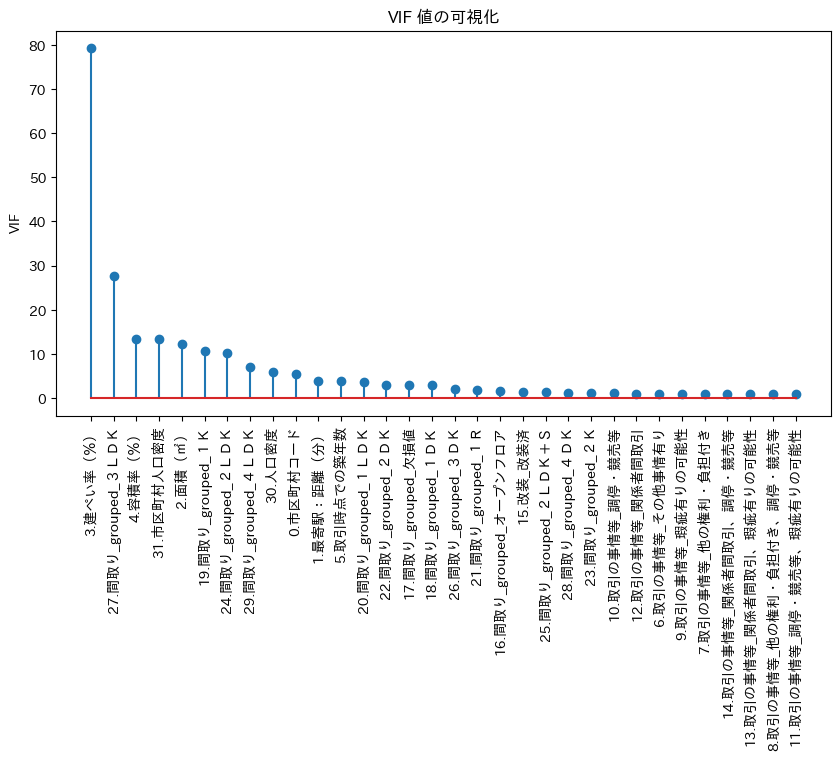

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.stem(vif.index.astype(str) + "." + vif["変数名"], vif["VIF"])
plt.xticks(rotation=90)
plt.ylabel("VIF")
plt.title("VIF 値の可視化")
plt.show()

## 10以下で再学習

In [37]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
import lightgbm as lgb
import pandas as pd
import numpy as np

# ========================================
# ステップ1: VIFの計算
# ========================================

print("=== ステップ1: VIF計算 ===")

# カテゴリ変数をLabel Encoding
categorical_cols = ['都道府県名', '市区町村名', '地区名', '最寄駅：名称']

X_for_vif = X.copy()
for col in categorical_cols:
    if col in X_for_vif.columns:
        le = LabelEncoder()
        X_for_vif[col] = le.fit_transform(X_for_vif[col].astype(str))

# 欠損値を除去
X_for_vif = X_for_vif.dropna()

# VIF計算
vif = pd.DataFrame()
vif["変数名"] = X_for_vif.columns
vif["VIF"] = [variance_inflation_factor(X_for_vif.values, i) for i in range(X_for_vif.shape[1])]
vif = vif.sort_values('VIF', ascending=False)

print("\n=== VIF結果（上位20個）===")
print(vif.head(20))

# VIF > 10 の変数を抽出
high_vif_cols = vif[vif['VIF'] > 10]['変数名'].tolist()
print(f"\n⚠️ VIF > 10 の変数: {len(high_vif_cols)}個")
if high_vif_cols:
    print(high_vif_cols)

# ========================================
# ステップ2: VIF > 10 の変数を削除
# ========================================

print("\n=== ステップ2: 変数削除 ===")

if len(high_vif_cols) > 0:
    X_filtered = X.drop(columns=high_vif_cols, errors='ignore')
    print(f"変数削除前: {X.shape[1]}個")
    print(f"変数削除後: {X_filtered.shape[1]}個")
    print(f"削除した変数: {len(high_vif_cols)}個")
else:
    X_filtered = X.copy()
    print("✓ 削除する変数はありません")

# ========================================
# ステップ3: カテゴリ変数を数値化
# ========================================

print("\n=== ステップ3: カテゴリ変数の数値化 ===")

X_filtered_encoded = X_filtered.copy()

for col in categorical_cols:
    if col in X_filtered_encoded.columns:
        le = LabelEncoder()
        X_filtered_encoded[col] = le.fit_transform(X_filtered_encoded[col].astype(str))

print(f"✓ カテゴリ変数を数値化しました")
print(f"最終特徴量数: {X_filtered_encoded.shape[1]}")

# ========================================
# ステップ4: データ分割
# ========================================

print("\n=== ステップ4: データ分割 ===")

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_filtered_encoded, Y, test_size=0.2, random_state=42
)

print(f"Train: {X_train_r.shape[0]}件")
print(f"Test:  {X_test_r.shape[0]}件")

# ========================================
# ステップ5: モデル学習（VIF調整後）
# ========================================

print("\n=== ステップ5: モデル学習（VIF調整後）===")

model_lgb_r = lgb.LGBMRegressor(
    objective='regression_l1',
    metric='mae',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

model_lgb_r.fit(
    X_train_r, y_train_r,
    eval_set=[(X_train_r, y_train_r), (X_test_r, y_test_r)],
    eval_names=['train', 'valid'],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

print(f"✓ 学習完了 (best iteration: {model_lgb_r.best_iteration_})")

# ========================================
# ステップ6: 評価
# ========================================

print("\n=== ステップ6: 評価 ===")

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_train_r = model_lgb_r.predict(X_train_r)
y_pred_test_r = model_lgb_r.predict(X_test_r)

mae_train_r = mean_absolute_error(y_train_r, y_pred_train_r)
mae_test_r = mean_absolute_error(y_test_r, y_pred_test_r)
rmse_train_r = np.sqrt(mean_squared_error(y_train_r, y_pred_train_r))
rmse_test_r = np.sqrt(mean_squared_error(y_test_r, y_pred_test_r))
r2_train_r = r2_score(y_train_r, y_pred_train_r)
r2_test_r = r2_score(y_test_r, y_pred_test_r)

print(f"\n=== VIF調整後のLightGBM評価結果 ===")
print(f"【Train】")
print(f"  MAE:  {mae_train_r:.4f}")
print(f"  RMSE: {rmse_train_r:.4f}")
print(f"  R²:   {r2_train_r:.4f}")
print(f"\n【Test】")
print(f"  MAE:  {mae_test_r:.4f}")
print(f"  RMSE: {rmse_test_r:.4f}")
print(f"  R²:   {r2_test_r:.4f}")

=== ステップ1: VIF計算 ===


\\?\C:\Users\sabri\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss



=== VIF結果（上位20個）===
                 変数名         VIF
38            面積_平方根  437.355322
37            面積_log  236.686561
6              面積（㎡）  172.469038
41           面積×建ぺい率  129.387271
9          取引時点での築年数   83.014163
40          築年数×建ぺい率   55.232989
31  間取り_grouped_３ＬＤＫ   34.289759
23    間取り_grouped_１Ｋ   23.646195
28  間取り_grouped_２ＬＤＫ   18.039123
7            建ぺい率（％）   17.914682
44       面積×建ぺい率×容積率   16.486278
39           築年数×駅距離   16.140162
33  間取り_grouped_４ＬＤＫ   12.123935
36            築年数_2乗   11.857433
43        築年数×面積×駅距離   11.334768
8             容積率（％）    9.748370
34              人口密度    8.799546
42           面積×人口密度    7.495972
24  間取り_grouped_１ＬＤＫ    6.930860
22   間取り_grouped_１ＤＫ    5.473120

⚠️ VIF > 10 の変数: 15個
['面積_平方根', '面積_log', '面積（㎡）', '面積×建ぺい率', '取引時点での築年数', '築年数×建ぺい率', '間取り_grouped_３ＬＤＫ', '間取り_grouped_１Ｋ', '間取り_grouped_２ＬＤＫ', '建ぺい率（％）', '面積×建ぺい率×容積率', '築年数×駅距離', '間取り_grouped_４ＬＤＫ', '築年数_2乗', '築年数×面積×駅距離']

=== ステップ2: 変数削除 ===
変数削除前: 57個
変数削除後: 42個
削除した変数: 15個

===

## 20以下

In [44]:

# ========================================
# ステップ1: VIFの計算
# ========================================

print("=== ステップ1: VIF計算 ===")

# カテゴリ変数をLabel Encoding
categorical_cols = ['都道府県名', '市区町村名', '地区名', '最寄駅：名称']

X_for_vif = X.copy()
for col in categorical_cols:
    if col in X_for_vif.columns:
        le = LabelEncoder()
        X_for_vif[col] = le.fit_transform(X_for_vif[col].astype(str))

# 欠損値を除去
X_for_vif = X_for_vif.dropna()

# VIF計算
vif = pd.DataFrame()
vif["変数名"] = X_for_vif.columns
vif["VIF"] = [variance_inflation_factor(X_for_vif.values, i) for i in range(X_for_vif.shape[1])]
vif = vif.sort_values('VIF', ascending=False)

print("\n=== VIF結果（上位20個）===")
print(vif.head(20))

# VIF > 10 の変数を抽出
high_vif_cols = vif[vif['VIF'] > 20]['変数名'].tolist()
print(f"\n⚠️ VIF > 20 の変数: {len(high_vif_cols)}個")
if high_vif_cols:
    print(high_vif_cols)

# ========================================
# ステップ2: VIF > 20 の変数を削除
# ========================================

print("\n=== ステップ2: 変数削除 ===")

if len(high_vif_cols) > 0:
    X_filtered = X.drop(columns=high_vif_cols, errors='ignore')
    print(f"変数削除前: {X.shape[1]}個")
    print(f"変数削除後: {X_filtered.shape[1]}個")
    print(f"削除した変数: {len(high_vif_cols)}個")
else:
    X_filtered = X.copy()
    print("✓ 削除する変数はありません")

# ========================================
# ステップ3: カテゴリ変数を数値化
# ========================================

print("\n=== ステップ3: カテゴリ変数の数値化 ===")

X_filtered_encoded = X_filtered.copy()

for col in categorical_cols:
    if col in X_filtered_encoded.columns:
        le = LabelEncoder()
        X_filtered_encoded[col] = le.fit_transform(X_filtered_encoded[col].astype(str))

print(f"✓ カテゴリ変数を数値化しました")
print(f"最終特徴量数: {X_filtered_encoded.shape[1]}")

# ========================================
# ステップ4: データ分割
# ========================================

print("\n=== ステップ4: データ分割 ===")

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_filtered_encoded, Y, test_size=0.2, random_state=42
)

print(f"Train: {X_train_r.shape[0]}件")
print(f"Test:  {X_test_r.shape[0]}件")

# ========================================
# ステップ5: モデル学習（VIF調整後）
# ========================================

print("\n=== ステップ5: モデル学習（VIF調整後）===")

model_lgb_r = lgb.LGBMRegressor(
    objective='regression_l1',
    metric='mae',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

model_lgb_r.fit(
    X_train_r, y_train_r,
    eval_set=[(X_train_r, y_train_r), (X_test_r, y_test_r)],
    eval_names=['train', 'valid'],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

print(f"✓ 学習完了 (best iteration: {model_lgb_r.best_iteration_})")

# ========================================
# ステップ6: 評価
# ========================================

print("\n=== ステップ6: 評価 ===")

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_train_r = model_lgb_r.predict(X_train_r)
y_pred_test_r = model_lgb_r.predict(X_test_r)

mae_train_r = mean_absolute_error(y_train_r, y_pred_train_r)
mae_test_r = mean_absolute_error(y_test_r, y_pred_test_r)
rmse_train_r = np.sqrt(mean_squared_error(y_train_r, y_pred_train_r))
rmse_test_r = np.sqrt(mean_squared_error(y_test_r, y_pred_test_r))
r2_train_r = r2_score(y_train_r, y_pred_train_r)
r2_test_r = r2_score(y_test_r, y_pred_test_r)

print(f"\n=== VIF調整後のLightGBM評価結果 ===")
print(f"【Train】")
print(f"  MAE:  {mae_train_r:.4f}")
print(f"  RMSE: {rmse_train_r:.4f}")
print(f"  R²:   {r2_train_r:.4f}")
print(f"\n【Test】")
print(f"  MAE:  {mae_test_r:.4f}")
print(f"  RMSE: {rmse_test_r:.4f}")
print(f"  R²:   {r2_test_r:.4f}")

=== ステップ1: VIF計算 ===


\\?\C:\Users\sabri\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss



=== VIF結果（上位20個）===
                 変数名         VIF
34            面積_平方根  191.860076
33            面積_log  128.266719
6          取引時点での築年数   52.171809
28  間取り_grouped_３ＬＤＫ   34.276066
36          築年数×建ぺい率   29.838224
37           面積×建ぺい率   25.012484
20    間取り_grouped_１Ｋ   23.621342
25  間取り_grouped_２ＬＤＫ   18.022217
35           築年数×駅距離   15.368749
30  間取り_grouped_４ＬＤＫ   12.114079
32            築年数_2乗   11.797157
39        築年数×面積×駅距離   10.088241
31              人口密度    7.511888
21  間取り_grouped_１ＬＤＫ    6.911394
38           面積×人口密度    6.889334
40       面積×建ぺい率×容積率    5.823590
19   間取り_grouped_１ＤＫ    5.461291
23   間取り_grouped_２ＤＫ    5.365059
18   間取り_grouped_欠損値    5.250801
48       市区町村_頻度_log    4.928380

⚠️ VIF > 20 の変数: 7個
['面積_平方根', '面積_log', '取引時点での築年数', '間取り_grouped_３ＬＤＫ', '築年数×建ぺい率', '面積×建ぺい率', '間取り_grouped_１Ｋ']

=== ステップ2: 変数削除 ===
変数削除前: 53個
変数削除後: 46個
削除した変数: 7個

=== ステップ3: カテゴリ変数の数値化 ===
✓ カテゴリ変数を数値化しました
最終特徴量数: 46

=== ステップ4: データ分割 ===
Train: 441316件
Test:  110329件

=== ステップ